In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import dismech_jax as djx
from Energy_NN import *

class Slinky1D(djx.System):
    """Simple 2-node 1D spring under exact displacement control."""

    l_k: jax.Array
    x_left: jax.Array

    def get_q(self, disp: jax.Array, q0: jax.Array) -> jax.Array:
        """
        disp is the exact prescribed displacement value for the pulled node.

        Left node is fixed at x_left.
        Right node is prescribed directly to disp.
        """
        q = q0.at[0].set(self.x_left)
        q = q.at[1].set(disp)
        return q

    def get_eps(self, q: jax.Array) -> jax.Array:
        return (q[1] - q[0]) / self.l_k - 1.0

    def get_E(
        self, _lambda: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        eps = self.get_eps(q)
        return model(jnp.array([eps]))

    def get_F(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        # No free DOFs in this 2-node fully prescribed toy problem.
        return jnp.zeros_like(q)

    def get_H(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        # Dummy Hessian for API compatibility.
        return jnp.eye(q.shape[0])

    def get_reaction_force(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        """
        Reaction force at the pulled (right) node.

        If your measured force has opposite sign convention,
        flip the sign here.
        """
        dEdq = jax.grad(self.get_E, argnums=1)(disp, q, model, aux)
        return dEdq[1]


In [2]:

# =========================================================
# Load data from saved format with exact displacements
# =========================================================
data = np.load("experiment_data/pulling_phase_data.npz")

force_truth = jnp.array(data["F"])         # shape (N,)
disps = jnp.array(data["disps"])           # exact pulled-node positions
initial_last_node_x = float(data["initial_last_node_x"])

num_steps = force_truth.shape[0]

# Two-node rod:
# node 0 fixed at x = 0
# node 1 starts at initial_last_node_x
x_left = 0.0
q0 = jnp.array([x_left, initial_last_node_x])

# Initial rest length
l_k0 = q0[1] - q0[0]

slinky = Slinky1D(
    l_k=jnp.array(l_k0),
    x_left=jnp.array(x_left),
)

model = ICNN_Energy(jax.random.PRNGKey(42), K_initial=0.1, weight_scale=1, hidden_sizes=(10,))



In [3]:

# =========================================================
# Train/test split
# Use displacement directly instead of lambda
# =========================================================
disp_min = disps.min()
disp_max = disps.max()

test_range = (
    disp_min + 0.2 * (disp_max - disp_min),
    disp_min + 0.8 * (disp_max - disp_min),
)

train_mask = (disps <= test_range[0]) | (disps >= test_range[1])
test_mask = (disps > test_range[0]) & (disps < test_range[1])

train_disps = disps[train_mask]
train_force_truth = force_truth[train_mask]

test_disps = disps[test_mask]
test_force_truth = force_truth[test_mask]

print("Num total samples:", num_steps)
print("Num train samples:", train_disps.shape[0])
print("Num test samples :", test_disps.shape[0])
print("Initial pulled-node x:", initial_last_node_x)
print("Rest length l_k0     :", l_k0)


# =========================================================
# Prediction: exact displacement -> prescribed q -> reaction force
# =========================================================
def predict_force(model, disp_vals):
    def one_force(disp):
        q = slinky.get_q(disp, q0)
        return slinky.get_reaction_force(disp, q, model, None)

    return jax.vmap(one_force)(disp_vals)


# =========================================================
# Loss
# =========================================================
def train_loss(model):
    pred_force = predict_force(model, train_disps)
    return jnp.mean((train_force_truth - pred_force) ** 2)


lr = 1e-2
schedule = optax.piecewise_constant_schedule(
    init_value=lr,
    # boundaries_and_scales={3000: 0.1, 6000: 0.1},
    boundaries_and_scales={7500: 0.1},
)
optimizer = optax.adam(learning_rate=schedule)

opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(carry, _):
    model, opt_state = carry
    loss_val, grads = eqx.filter_value_and_grad(train_loss)(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return (model, opt_state), loss_val


num_epochs = 10000
log_freq = 500


def train_loop(model, opt_state):
    def scan_fn(carry, i):
        next_carry, loss_val = train_step(carry, None)

        def log_loss(_):
            jax.debug.print("Epoch: {x}, Train Loss: {y}", x=i, y=loss_val)

        jax.lax.cond(i % log_freq == 0, log_loss, lambda _: None, operand=None)
        return next_carry, loss_val

    (final_model, final_opt_state), loss_history = jax.lax.scan(
        scan_fn, (model, opt_state), jnp.arange(num_epochs + 1)
    )
    return final_model, loss_history


final_model, loss_history = train_loop(model, opt_state)


# =========================================================
# Evaluate on full displacement trajectory
# =========================================================
pred_full_force = predict_force(final_model, disps)

train_mse = jnp.mean((force_truth[train_mask] - pred_full_force[train_mask]) ** 2)
test_mse = jnp.mean((force_truth[test_mask] - pred_full_force[test_mask]) ** 2)

print("Final train force MSE:", train_mse)
print("Final test  force MSE:", test_mse)

Num total samples: 179
Num train samples: 79
Num test samples : 100
Initial pulled-node x: 0.2
Rest length l_k0     : 0.2
Epoch: 0, Train Loss: 42.084259033203125
Epoch: 500, Train Loss: 2.461362600326538
Epoch: 1000, Train Loss: 2.43588924407959
Epoch: 1500, Train Loss: 2.4253971576690674
Epoch: 2000, Train Loss: 2.406008720397949
Epoch: 2500, Train Loss: 2.0048601627349854
Epoch: 3000, Train Loss: 0.05312581732869148
Epoch: 3500, Train Loss: 0.031186988577246666
Epoch: 4000, Train Loss: 0.028855593875050545
Epoch: 4500, Train Loss: 0.026773573830723763
Epoch: 5000, Train Loss: 0.02495696023106575
Epoch: 5500, Train Loss: 0.023839039728045464
Epoch: 6000, Train Loss: 0.023337142542004585
Epoch: 6500, Train Loss: 0.02310829609632492
Epoch: 7000, Train Loss: 0.02296745777130127
Epoch: 7500, Train Loss: 0.022866446524858475
Epoch: 8000, Train Loss: 0.02285683900117874
Epoch: 8500, Train Loss: 0.02284506894648075
Epoch: 9000, Train Loss: 0.022830797359347343
Epoch: 9500, Train Loss: 0.022

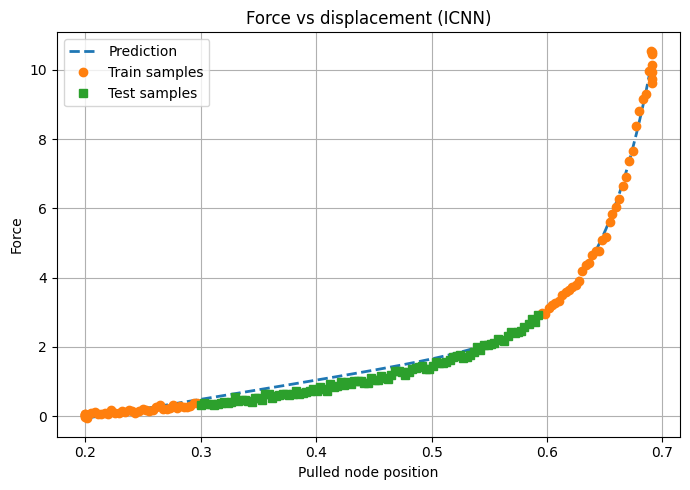

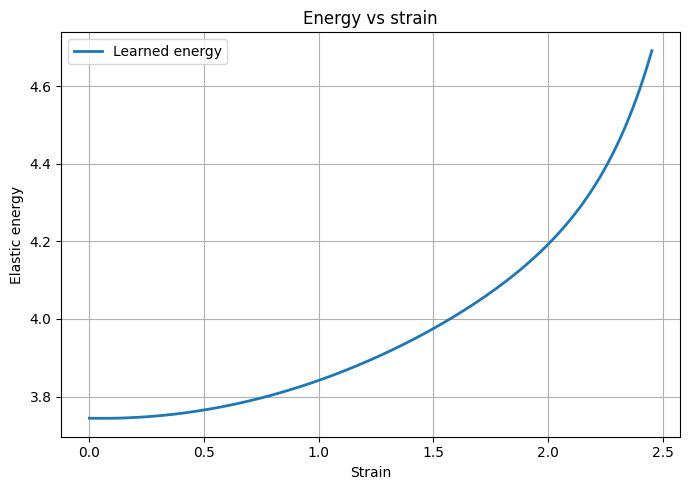

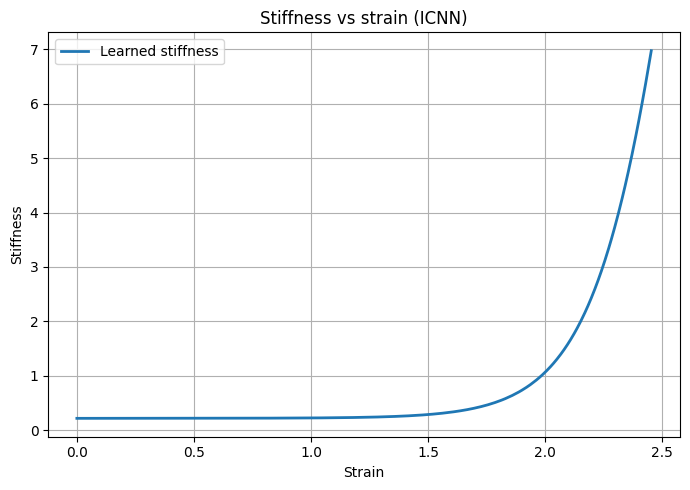

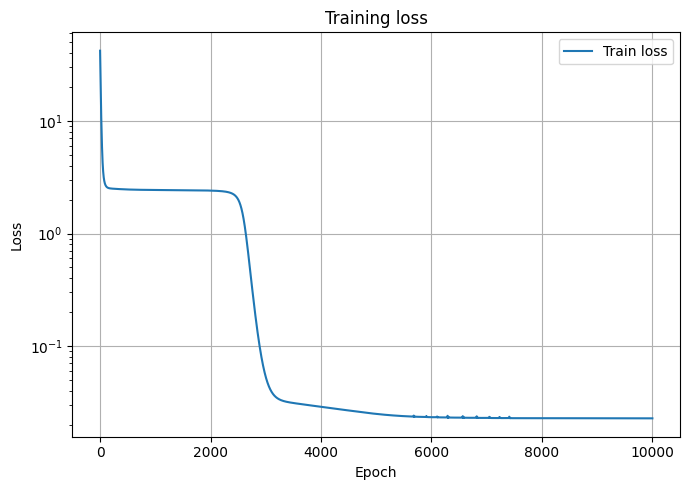

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp

# =========================================================
# Convert everything to numpy
# =========================================================
disps_np = np.array(disps)
force_truth_np = np.array(force_truth)
pred_full_force_np = np.array(pred_full_force)

train_mask_np = np.array(train_mask)
test_mask_np = np.array(test_mask)


# =========================================================
# 1. Force vs displacement
# =========================================================
plt.figure(figsize=(7, 5))

# Prediction curve
plt.plot(disps_np, pred_full_force_np, "--", linewidth=2, label="Prediction")

# Ground truth samples
plt.plot(
    disps_np[train_mask_np],
    force_truth_np[train_mask_np],
    "o",
    markersize=6,
    label="Train samples",
)

plt.plot(
    disps_np[test_mask_np],
    force_truth_np[test_mask_np],
    "s",
    markersize=6,
    label="Test samples",
)

plt.xlabel("Pulled node position")
plt.ylabel("Force")
plt.title("Force vs displacement (ICNN)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 2. Strain computation (IMPORTANT FIX)
# =========================================================
# Build q from actual displacements (NOT lambdas)
qs = jax.vmap(lambda d: slinky.get_q(d, q0))(disps)

# Compute strain
strains = jax.vmap(slinky.get_eps)(qs)

strains_np = np.array(strains)


# =========================================================
# 3. Energy vs strain
# =========================================================
Energy = jax.vmap(lambda eps: final_model(jnp.array([eps])))(strains)
Energy_np = np.array(Energy)

# Sort for clean curve
sort_idx = np.argsort(strains_np)

plt.figure(figsize=(7, 5))
plt.plot(
    strains_np[sort_idx],
    Energy_np[sort_idx],
    linewidth=2,
    label="Learned energy",
)

plt.xlabel("Strain")
plt.ylabel("Elastic energy")
plt.title("Energy vs strain")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 4. Stiffness vs strain (FIXED)
# =========================================================
def energy_scalar(eps):
    return final_model(jnp.array([eps]))

# First derivative: force wrt strain
dE_deps = jax.grad(energy_scalar)

# Second derivative: stiffness
d2E_deps2 = jax.grad(dE_deps)

stiffness = jax.vmap(d2E_deps2)(strains)
stiffness_np = np.array(stiffness)

plt.figure(figsize=(7, 5))
plt.plot(
    strains_np[sort_idx],
    stiffness_np[sort_idx],
    linewidth=2,
    label="Learned stiffness",
)

plt.xlabel("Strain")
plt.ylabel("Stiffness")
plt.title("Stiffness vs strain (ICNN)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 5. Training loss history (FIXED)
# =========================================================
loss_history_np = np.array(loss_history)

plt.figure(figsize=(7, 5))
plt.plot(loss_history_np, label="Train loss")
plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
strain_np = np.array(strains)

def get_K_scalar(eps_scalar):
    return final_model.get_K(jnp.array([eps_scalar]))

def get_delta_scalar(eps_scalar):
    return final_model.K_mlp(jnp.array([eps_scalar]))

delta_vals = jax.vmap(get_delta_scalar)(strains)
K_total_vals = jax.vmap(get_K_scalar)(strains)

K0_val = final_model.K_baseline()
K0_vals = jnp.ones_like(K_total_vals) * K0_val

K_total_np = np.array(K_total_vals)
delta_np = np.array(delta_vals)
K0_np = np.array(K0_vals)

idx = np.argsort(strain_np)

strain_np = strain_np[idx]
K_total_np = K_total_np[idx]
delta_np = delta_np[idx]
K0_np = K0_np[idx]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------
# (a) Baseline vs total stiffness
# -----------------------------------
axs[0].plot(strain_np, K_total_np, linewidth=2, label="Total K(ε)")
axs[0].plot(strain_np, K0_np, "--", linewidth=2, label="Baseline K0")
axs[0].set_xlabel("Strain")
axs[0].set_ylabel("Stiffness")
axs[0].set_title("Baseline vs total stiffness")
axs[0].legend()
axs[0].grid(True)

# -----------------------------------
# (b) MLP correction
# -----------------------------------
axs[1].plot(strain_np, delta_np, linewidth=2, label="MLP correction (raw)")
axs[1].set_xlabel("Strain")
axs[1].set_ylabel("ΔK (before softplus)")
axs[1].set_title("MLP correction vs strain")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

AttributeError: 'ICNN_Energy' object has no attribute 'K_mlp'